# 问题一：全变量滞后特征重新建模测试

本 notebook 用于重新测试问题一模型。当前版本不再使用 `selected-one-lag` 数据，而是读取：

```text
data/all_variable_lag_features.xlsx
```

该数据文件的特点是：

```text
1. 所有可用变量都构造了滞后特征；
2. 不做相关性筛选；
3. 不做 best-lag 选择；
4. 保留所有数值型 lag 特征；
5. 输入缺失值使用训练集 median imputer 处理；
6. 模型对比包括 Random Forest、XGBoost 和 GAM。
```

注意：

```text
NTU_lag0 不应作为输入变量，因为它等于当前预测目标 target_NTU，会造成目标泄漏。
```


## 1. 导入依赖库

这一部分导入建模、数据处理、可视化和模型保存所需的 Python 库。  
如果环境中没有安装 `xgboost`，notebook 会自动跳过 XGBoost，只运行 Random Forest 和 GAM。


In [1]:
from pathlib import Path
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = e

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

print("依赖库导入完成。")
print("XGBoost 是否可用：", XGBOOST_AVAILABLE)


依赖库导入完成。
XGBoost 是否可用： True


## 2. 参数设置

这里统一设置目标变量、训练集比例、目标预测日期、是否进行 NTU clipping，以及输出目录名称。

默认情况下，本 notebook **不进行 NTU clipping**，因为这里的目的是单独测试“全变量全滞后特征”的效果。  
如果需要与 `p1_4.ipynb` 的 clipping 版本保持一致，可以将：

```python
CLIP_NTU_RELATED_VALUES = True
```


In [2]:
# =========================
# 基础设置
# =========================

TARGET_COL = "target_NTU"

# 按时间顺序划分训练集和测试集
TRAIN_RATIO = 0.80
RANDOM_STATE = 42

# 题目要求预测的运行日
TARGET_OP_DATES = [
    "2026-02-01",
    "2026-02-10",
    "2026-02-20",
]

# 是否删除全空特征
DROP_ALL_EMPTY_FEATURES = True

# 是否对 NTU 相关变量进行上限截断
# 默认关闭，用于单独测试 all-lag 数据本身的效果
CLIP_NTU_RELATED_VALUES = False
CLIP_NTU_UPPER = 2.0

# 模型参数
N_ESTIMATORS_RF = 500
N_ESTIMATORS_XGB = 500

# 输出目录。单独保存，避免覆盖之前 p1_4 的结果
OUTPUT_DIR_NAME = "problem1_all_lag"

print("参数设置完成。")


参数设置完成。


## 3. 定位数据文件

本 notebook 会自动寻找：

```text
all_variable_lag_features.xlsx
```

优先查找：

```text
data/all_variable_lag_features.xlsx
../data/all_variable_lag_features.xlsx
```

如果当前工作目录不一致，也会向上级目录和项目目录中搜索。


In [3]:
def locate_data_file(filename="all_variable_lag_features.xlsx"):
    """
    自动定位 all_variable_lag_features.xlsx。
    适配从项目根目录运行或从 codes/ 文件夹运行两种情况。
    """
    cwd = Path.cwd().resolve()

    candidates = []
    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    # 去重
    seen = set()
    unique_candidates = []
    for path in candidates:
        path = path.resolve()
        if path not in seen:
            seen.add(path)
            unique_candidates.append(path)

    for path in unique_candidates:
        if path.exists():
            return path

    # 最后在当前目录下递归搜索
    for path in cwd.rglob(filename):
        return path.resolve()

    searched = "\n".join(str(path) for path in unique_candidates)
    raise FileNotFoundError(
        f"未找到 {filename}。已检查路径：\n{searched}"
    )


DATA_PATH = locate_data_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\all_variable_lag_features.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag


## 4. 读取全变量滞后数据

这里读取 `all_variable_lag_features.xlsx`。

该文件应包含：

```text
DATETIME
OP_DATE
target_NTU
各变量_lag0
各变量_lag1
...
各变量_lag12
NTU_lag1
...
NTU_lag12
```

其中 `target_NTU` 是当前时刻需要预测的出厂水浊度。


In [4]:
raw_df = pd.read_excel(DATA_PATH)

print("原始数据规模：", raw_df.shape)
print("前 40 个列名：")
print(raw_df.columns.tolist()[:40])

if TARGET_COL not in raw_df.columns:
    if "NTU" in raw_df.columns:
        raise ValueError(
            "当前文件里存在原始 NTU，但没有 target_NTU。"
            "请确认读取的是 all_variable_lag_features.xlsx，而不是 merged.xlsx。"
        )
    raise ValueError(f"未找到目标列：{TARGET_COL}")

display(raw_df.head())


原始数据规模： (5460, 210)
前 40 个列名：
['DATETIME', 'OP_DATE', 'target_NTU', 'RIVER LEVEL_lag0', 'RIVER LEVEL_lag1', 'RIVER LEVEL_lag2', 'RIVER LEVEL_lag3', 'RIVER LEVEL_lag4', 'RIVER LEVEL_lag5', 'RIVER LEVEL_lag6', 'RIVER LEVEL_lag7', 'RIVER LEVEL_lag8', 'RIVER LEVEL_lag9', 'RIVER LEVEL_lag10', 'RIVER LEVEL_lag11', 'RIVER LEVEL_lag12', 'R/W FLOW_lag0', 'R/W FLOW_lag1', 'R/W FLOW_lag2', 'R/W FLOW_lag3', 'R/W FLOW_lag4', 'R/W FLOW_lag5', 'R/W FLOW_lag6', 'R/W FLOW_lag7', 'R/W FLOW_lag8', 'R/W FLOW_lag9', 'R/W FLOW_lag10', 'R/W FLOW_lag11', 'R/W FLOW_lag12', 'R/W NTU_lag0', 'R/W NTU_lag1', 'R/W NTU_lag2', 'R/W NTU_lag3', 'R/W NTU_lag4', 'R/W NTU_lag5', 'R/W NTU_lag6', 'R/W NTU_lag7', 'R/W NTU_lag8', 'R/W NTU_lag9', 'R/W NTU_lag10']


,DATETIME,OP_DATE,target_NTU,RIVER LEVEL_lag0,RIVER LEVEL_lag1,RIVER LEVEL_lag2,RIVER LEVEL_lag3,RIVER LEVEL_lag4,RIVER LEVEL_lag5,RIVER LEVEL_lag6,RIVER LEVEL_lag7,RIVER LEVEL_lag8,RIVER LEVEL_lag9,RIVER LEVEL_lag10,RIVER LEVEL_lag11,RIVER LEVEL_lag12,R/W FLOW_lag0,R/W FLOW_lag1,R/W FLOW_lag2,R/W FLOW_lag3,R/W FLOW_lag4,R/W FLOW_lag5,R/W FLOW_lag6,R/W FLOW_lag7,R/W FLOW_lag8,R/W FLOW_lag9,R/W FLOW_lag10,R/W FLOW_lag11,R/W FLOW_lag12,R/W NTU_lag0,R/W NTU_lag1,R/W NTU_lag2,R/W NTU_lag3,R/W NTU_lag4,R/W NTU_lag5,R/W NTU_lag6,R/W NTU_lag7,R/W NTU_lag8,R/W NTU_lag9,R/W NTU_lag10,R/W NTU_lag11,R/W NTU_lag12,R/W CLR_lag0,R/W CLR_lag1,R/W CLR_lag2,R/W CLR_lag3,R/W CLR_lag4,R/W CLR_lag5,R/W CLR_lag6,R/W CLR_lag7,R/W CLR_lag8,R/W CLR_lag9,R/W CLR_lag10,R/W CLR_lag11,R/W CLR_lag12,R/W PH_lag0,R/W PH_lag1,R/W PH_lag2,R/W PH_lag3,R/W PH_lag4,R/W PH_lag5,R/W PH_lag6,R/W PH_lag7,R/W PH_lag8,R/W PH_lag9,R/W PH_lag10,R/W PH_lag11,R/W PH_lag12,FILT. NTU_lag0,FILT. NTU_lag1,FILT. NTU_lag2,FILT. NTU_lag3,FILT. NTU_lag4,FILT. NTU_lag5,FILT. NTU_lag6,FILT. NTU_lag7,FILT. NTU_lag8,FILT. NTU_lag9,FILT. NTU_lag10,FILT. NTU_lag11,...,CL2_lag10,CL2_lag11,CL2_lag12,F/RIDE_lag0,F/RIDE_lag1,F/RIDE_lag2,F/RIDE_lag3,F/RIDE_lag4,F/RIDE_lag5,F/RIDE_lag6,F/RIDE_lag7,F/RIDE_lag8,F/RIDE_lag9,F/RIDE_lag10,F/RIDE_lag11,F/RIDE_lag12,ALUM_lag0,ALUM_lag1,ALUM_lag2,ALUM_lag3,ALUM_lag4,ALUM_lag5,ALUM_lag6,ALUM_lag7,ALUM_lag8,ALUM_lag9,ALUM_lag10,ALUM_lag11,ALUM_lag12,T/W FLOW_lag0,T/W FLOW_lag1,T/W FLOW_lag2,T/W FLOW_lag3,T/W FLOW_lag4,T/W FLOW_lag5,T/W FLOW_lag6,T/W FLOW_lag7,T/W FLOW_lag8,T/W FLOW_lag9,T/W FLOW_lag10,T/W FLOW_lag11,T/W FLOW_lag12,R/W PUMP COUNT_lag0,R/W PUMP COUNT_lag1,R/W PUMP COUNT_lag2,R/W PUMP COUNT_lag3,R/W PUMP COUNT_lag4,R/W PUMP COUNT_lag5,R/W PUMP COUNT_lag6,R/W PUMP COUNT_lag7,R/W PUMP COUNT_lag8,R/W PUMP COUNT_lag9,R/W PUMP COUNT_lag10,R/W PUMP COUNT_lag11,R/W PUMP COUNT_lag12,T/W PUMP COUNT_lag0,T/W PUMP COUNT_lag1,T/W PUMP COUNT_lag2,T/W PUMP COUNT_lag3,T/W PUMP COUNT_lag4,T/W PUMP COUNT_lag5,T/W PUMP COUNT_lag6,T/W PUMP COUNT_lag7,T/W PUMP COUNT_lag8,T/W PUMP COUNT_lag9,T/W PUMP COUNT_lag10,T/W PUMP COUNT_lag11,T/W PUMP COUNT_lag12,NTU_lag1,NTU_lag2,NTU_lag3,NTU_lag4,NTU_lag5,NTU_lag6,NTU_lag7,NTU_lag8,NTU_lag9,NTU_lag10,NTU_lag11,NTU_lag12
0,2025-01-01 07:00:00,2025-01-01,0.12,6.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,850.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.12,6.34,6.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,830.0,850.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.04,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.6,42.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,2025-01-01,0.12,6.17,6.34,6.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.9,45.2,45.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82,120.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,780.0,830.0,850.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,.

## 5. 构造时间列和运行日 OP_DATE

如果数据中已经存在 `DATETIME` 和 `OP_DATE`，则直接使用。  
如果没有 `OP_DATE`，则按照水厂运行日规则重新构造：

```text
07:00, 09:00, ..., 23:00, 次日 01:00, 03:00, 05:00
```

属于同一个运行日。


In [5]:
# 构造 TIMESTAMP
if "DATETIME" in raw_df.columns:
    raw_df["TIMESTAMP"] = pd.to_datetime(raw_df["DATETIME"], errors="coerce")
elif "TIMESTAMP" in raw_df.columns:
    raw_df["TIMESTAMP"] = pd.to_datetime(raw_df["TIMESTAMP"], errors="coerce")
elif "DATE" in raw_df.columns and "TIME" in raw_df.columns:
    time_text = raw_df["TIME"].astype(str).str.split().str[-1]
    raw_df["TIMESTAMP"] = pd.to_datetime(
        raw_df["DATE"].astype(str).str.split().str[0] + " " + time_text,
        errors="coerce",
    )
else:
    raise ValueError("无法构造时间列：未找到 DATETIME / TIMESTAMP / DATE+TIME。")

# 构造或整理 OP_DATE
if "OP_DATE" in raw_df.columns:
    raw_df["OP_DATE"] = pd.to_datetime(raw_df["OP_DATE"], errors="coerce").dt.date
else:
    raw_df["OP_DATE"] = raw_df["TIMESTAMP"].dt.date
    mask_before_7 = raw_df["TIMESTAMP"].dt.hour < 7
    raw_df.loc[mask_before_7, "OP_DATE"] = (
        raw_df.loc[mask_before_7, "TIMESTAMP"] - pd.Timedelta(days=1)
    ).dt.date

# 目标变量转为数值
raw_df[TARGET_COL] = pd.to_numeric(raw_df[TARGET_COL], errors="coerce")

# 删除目标变量和时间缺失的行
raw_df = (
    raw_df.dropna(subset=[TARGET_COL, "TIMESTAMP"])
    .sort_values("TIMESTAMP")
    .reset_index(drop=True)
)

print("删除目标变量和时间缺失后的数据规模：", raw_df.shape)
print("时间范围：", raw_df["TIMESTAMP"].min(), "至", raw_df["TIMESTAMP"].max())
print("目标变量描述统计：")
display(raw_df[TARGET_COL].describe())

display(raw_df[["TIMESTAMP", "OP_DATE", TARGET_COL]].head(15))


删除目标变量和时间缺失后的数据规模： (5124, 211)
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00
目标变量描述统计：


count    5124.000000
mean        0.445794
std         0.616311
min         0.080000
25%         0.200000
50%         0.310000
75%         0.510000
max        11.900000
Name: target_NTU, dtype: float64

,TIMESTAMP,OP_DATE,target_NTU
0,2025-01-01 07:00:00,2025-01-01,0.12
1,2025-01-01 09:00:00,2025-01-01,0.12
2,2025-01-01 11:00:00,2025-01-01,0.12
3,2025-01-01 13:00:00,2025-01-01,0.11
4,2025-01-01 15:00:00,2025-01-01,0.11
5,2025-01-01 17:00:00,2025-01-01,0.11
6,2025-01-01 19:00:00,2025-01-01,0.11
7,2025-01-01 21:00:00,2025-01-01,0.11
8,2025-01-01 23:00:00,2025-01-01,0.12
9,2025-01-02 01:00:00,2025-01-01,0.12


## 6. 可选：NTU 上限截断处理

默认情况下，这一步不执行。  
如果打开 `CLIP_NTU_RELATED_VALUES = True`，则会将所有列名中包含 `NTU` 的变量中大于 2 的值映射为 2：

```text
NTU_clipped = min(NTU, 2)
```

当前 notebook 默认关闭，是为了单独测试全变量滞后数据本身的效果。


In [6]:
clip_records = []

if CLIP_NTU_RELATED_VALUES:
    ntu_related_cols = [
        col for col in raw_df.columns
        if "NTU" in col.upper()
    ]

    for col in ntu_related_cols:
        raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

        count_above_before = int((raw_df[col] > CLIP_NTU_UPPER).sum())
        max_before = raw_df[col].max(skipna=True)

        raw_df[col] = raw_df[col].clip(upper=CLIP_NTU_UPPER)

        count_above_after = int((raw_df[col] > CLIP_NTU_UPPER).sum())
        max_after = raw_df[col].max(skipna=True)

        clip_records.append({
            "column": col,
            "count_above_clip_before": count_above_before,
            "max_before": max_before,
            "clip_upper": CLIP_NTU_UPPER,
            "count_above_clip_after": count_above_after,
            "max_after": max_after,
        })

    clip_df = pd.DataFrame(clip_records)
    clip_path = OUTPUT_DIR / "all_lag_ntu_clip_report.xlsx"
    clip_df.to_excel(clip_path, index=False)

    print("已启用 NTU clipping。检查表已保存：", clip_path)
    display(clip_df)
else:
    print("当前未启用 NTU clipping。")


当前未启用 NTU clipping。


## 7. 数据质量审计

这里输出每一列的数据类型、缺失数量、缺失率和唯一值数量。  
该表用于确认全滞后数据中的缺失情况，尤其是高阶 lag 特征产生的天然缺失。


In [7]:
data_audit = pd.DataFrame({
    "column": raw_df.columns,
    "dtype": raw_df.dtypes.astype(str).values,
    "missing_count": raw_df.isna().sum().values,
    "missing_rate": raw_df.isna().mean().values,
    "unique_count": raw_df.nunique(dropna=True).values,
})

data_audit = data_audit.sort_values("missing_rate", ascending=False)

audit_path = OUTPUT_DIR / "all_lag_data_audit.xlsx"
data_audit.to_excel(audit_path, index=False)

print("数据审计表已保存：", audit_path)

data_audit_display = data_audit.copy()
data_audit_display["missing_rate"] = data_audit_display["missing_rate"].map(lambda x: f"{x:.2%}")

display(data_audit_display.head(30))


数据审计表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_data_audit.xlsx


,column,dtype,missing_count,missing_rate,unique_count
184,R/W PUMP COUNT_lag12,float64,1740,33.96%,1
183,R/W PUMP COUNT_lag11,float64,1739,33.94%,1
182,R/W PUMP COUNT_lag10,float64,1738,33.92%,1
181,R/W PUMP COUNT_lag9,float64,1737,33.90%,1
180,R/W PUMP COUNT_lag8,float64,1736,33.88%,1
179,R/W PUMP COUNT_lag7,float64,1735,33.86%,1
178,R/W PUMP COUNT_lag6,float64,1734,33.84%,1
177,R/W PUMP COUNT_lag5,float64,1733,33.82%,1
176,R/W PUMP COUNT_lag4,float64,1732,33.80%,1
175,R/W PUMP COUNT_lag3,float64,1731,33.78%,1


## 8. 构造全滞后输入特征集

这里从数据中筛选建模输入特征。

处理原则：

```text
1. 删除时间列、日期列、运行日列和目标列；
2. 只保留数值型特征；
3. 删除全空特征；
4. 不做相关性筛选；
5. 不做 best-lag 选择；
6. 保留所有可用的 lag 特征。
```

输入缺失值不会在这里直接删除，而是在建模 pipeline 中使用训练集 median imputer 处理。


In [8]:
NON_FEATURE_COLUMNS = {
    "DATE", "Date", "date",
    "TIME", "Time", "time",
    "DATETIME",
    "TIMESTAMP",
    "OP_DATE",
    "REMARKS",
    TARGET_COL,
}

candidate_features = [
    col for col in raw_df.columns
    if col not in NON_FEATURE_COLUMNS
]

# 尝试将候选特征转为数值型
numeric_features = []
non_numeric_dropped = []

for col in candidate_features:
    raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")
    if pd.api.types.is_numeric_dtype(raw_df[col]):
        numeric_features.append(col)
    else:
        non_numeric_dropped.append(col)

# 删除全空特征
all_empty_features = [
    col for col in numeric_features
    if raw_df[col].isna().all()
]

if DROP_ALL_EMPTY_FEATURES:
    feature_cols = [
        col for col in numeric_features
        if col not in all_empty_features
    ]
else:
    feature_cols = numeric_features

# 防止目标泄漏
leakage_cols = [col for col in feature_cols if col == "NTU_lag0" or col == TARGET_COL]
if len(leakage_cols) > 0:
    raise ValueError(f"发现可能导致目标泄漏的列：{leakage_cols}")

feature_summary = pd.DataFrame({
    "feature": feature_cols,
    "missing_count": raw_df[feature_cols].isna().sum().values,
    "missing_rate": raw_df[feature_cols].isna().mean().values,
    "non_missing_count": raw_df[feature_cols].notna().sum().values,
})

feature_summary = feature_summary.sort_values("missing_rate", ascending=False)

feature_summary_path = OUTPUT_DIR / "all_lag_feature_summary.xlsx"
feature_summary.to_excel(feature_summary_path, index=False)

print("候选数值特征数：", len(numeric_features))
print("删除的全空特征数：", len(all_empty_features))
print("最终进入模型的全滞后特征数：", len(feature_cols))
print("特征汇总表已保存：", feature_summary_path)

print("\n前 50 个输入特征：")
print(feature_cols[:50])

feature_summary_display = feature_summary.copy()
feature_summary_display["missing_rate"] = feature_summary_display["missing_rate"].map(lambda x: f"{x:.2%}")
display(feature_summary_display.head(30))


候选数值特征数： 207
删除的全空特征数： 0
最终进入模型的全滞后特征数： 207
特征汇总表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_feature_summary.xlsx

前 50 个输入特征：
['RIVER LEVEL_lag0', 'RIVER LEVEL_lag1', 'RIVER LEVEL_lag2', 'RIVER LEVEL_lag3', 'RIVER LEVEL_lag4', 'RIVER LEVEL_lag5', 'RIVER LEVEL_lag6', 'RIVER LEVEL_lag7', 'RIVER LEVEL_lag8', 'RIVER LEVEL_lag9', 'RIVER LEVEL_lag10', 'RIVER LEVEL_lag11', 'RIVER LEVEL_lag12', 'R/W FLOW_lag0', 'R/W FLOW_lag1', 'R/W FLOW_lag2', 'R/W FLOW_lag3', 'R/W FLOW_lag4', 'R/W FLOW_lag5', 'R/W FLOW_lag6', 'R/W FLOW_lag7', 'R/W FLOW_lag8', 'R/W FLOW_lag9', 'R/W FLOW_lag10', 'R/W FLOW_lag11', 'R/W FLOW_lag12', 'R/W NTU_lag0', 'R/W NTU_lag1', 'R/W NTU_lag2', 'R/W NTU_lag3', 'R/W NTU_lag4', 'R/W NTU_lag5', 'R/W NTU_lag6', 'R/W NTU_lag7', 'R/W NTU_lag8', 'R/W NTU_lag9', 'R/W NTU_lag10', 'R/W NTU_lag11', 'R/W NTU_lag12', 'R/W CLR_lag0', 'R/W CLR_lag1', 'R/W CLR_lag2', 'R/W CLR_lag3', 'R/W CLR_lag4', 'R/W CLR_lag5', 'R/W CLR_lag6', 'R/W CLR_lag7', 'R/W CLR_lag8', 'R/W

,feature,missing_count,missing_rate,non_missing_count
181,R/W PUMP COUNT_lag12,1740,33.96%,3384
180,R/W PUMP COUNT_lag11,1739,33.94%,3385
179,R/W PUMP COUNT_lag10,1738,33.92%,3386
178,R/W PUMP COUNT_lag9,1737,33.90%,3387
177,R/W PUMP COUNT_lag8,1736,33.88%,3388
176,R/W PUMP COUNT_lag7,1735,33.86%,3389
175,R/W PUMP COUNT_lag6,1734,33.84%,3390
174,R/W PUMP COUNT_lag5,1733,33.82%,3391
173,R/W PUMP COUNT_lag4,1732,33.80%,3392
172,R/W PUMP COUNT_lag3,1731,33.78%,3393


## 9. 分离题目指定预测日期

题目要求预测三个运行日：

```text
2026-02-01
2026-02-10
2026-02-20
```

为了避免目标日期信息进入训练过程，这里先将这些运行日的数据单独取出。  
剩余数据用于训练集和测试集划分。


In [9]:
target_dates = pd.to_datetime(TARGET_OP_DATES).date
target_date_mask = raw_df["OP_DATE"].isin(target_dates)

model_df = raw_df.loc[~target_date_mask].copy()
target_dates_df = raw_df.loc[target_date_mask].copy()

print("用于训练和测试的数据行数：", model_df.shape[0])
print("用于指定日期预测的数据行数：", target_dates_df.shape[0])

print("\n指定预测日期样本数：")
display(target_dates_df["OP_DATE"].value_counts().sort_index())


用于训练和测试的数据行数： 5124
用于指定日期预测的数据行数： 0

指定预测日期样本数：


Series([], Name: count, dtype: int64)

## 10. 按时间顺序划分训练集和测试集

由于水质数据具有时间序列属性，因此这里不使用随机划分，而是按照时间顺序划分：

```text
前 80%：训练集
后 20%：测试集
```

这样更接近真实预测场景，也能避免随机划分带来的时间信息泄漏。


In [10]:
model_df = model_df.sort_values("TIMESTAMP").reset_index(drop=True)

split_idx = int(len(model_df) * TRAIN_RATIO)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

print("训练集特征矩阵：", X_train.shape)
print("测试集特征矩阵：", X_test.shape)

print("\n训练集时间范围：", train_df["TIMESTAMP"].min(), "至", train_df["TIMESTAMP"].max())
print("测试集时间范围：", test_df["TIMESTAMP"].min(), "至", test_df["TIMESTAMP"].max())


训练集特征矩阵： (4099, 207)
测试集特征矩阵： (1025, 207)

训练集时间范围： 2025-01-01 07:00:00 至 2025-12-08 19:00:00
测试集时间范围： 2025-12-08 21:00:00 至 2026-04-01 05:00:00


## 11. 建立建模 pipeline

输入特征处理流程：

```text
SimpleImputer(strategy="median")
↓
StandardScaler()
↓
模型训练
```

使用 median imputer 的原因：

```text
1. 高阶 lag 特征在时间序列开头天然缺失；
2. 原始数据中部分变量本身也存在缺失；
3. 直接 dropna 会导致样本大量减少；
4. 中位数比均值更不容易受极端值影响；
5. imputer 放在 pipeline 中，可以保证只用训练集统计量，避免数据泄漏。
```

对比模型包括：

```text
1. Random Forest
2. XGBoost
3. GAM：SplineTransformer + Ridge
```


In [11]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, feature_cols)
    ],
    remainder="drop"
)

models = {}

models["All-lag Random Forest"] = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=N_ESTIMATORS_RF,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_features="sqrt",
        min_samples_leaf=2,
    ))
])

if XGBOOST_AVAILABLE:
    models["All-lag XGBoost"] = Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            n_estimators=N_ESTIMATORS_XGB,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ])
else:
    print("当前环境无法导入 XGBoost，将跳过 XGBoost。")
    print("错误信息：", XGBOOST_IMPORT_ERROR)

models["All-lag GAM"] = Pipeline([
    ("preprocess", preprocessor),
    ("model", Pipeline([
        ("spline", SplineTransformer(
            n_knots=5,
            degree=3,
            include_bias=False,
        )),
        ("ridge", Ridge(alpha=10.0))
    ]))
])

print("待训练模型：")
print(list(models.keys()))


待训练模型：
['All-lag Random Forest', 'All-lag XGBoost', 'All-lag GAM']


## 12. 模型训练与测试集评估

评价指标包括：

```text
MAE
RMSE
R²
MAPE
```

其中论文中建议主要讨论：

```text
MAE、RMSE、R²
```

因为 NTU 数值较小时，MAPE 容易被放大。


In [12]:
def safe_mape(y_true, y_pred, eps=1e-6):
    """
    计算 MAPE。
    为避免 y_true 接近 0 时除零，使用 eps 作为最小分母。
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


result_records = []
prediction_records = []
fitted_models = {}

for model_name, pipe in models.items():
    print("\n" + "=" * 80)
    print("正在训练模型：", model_name)
    print("=" * 80)

    pipe.fit(X_train, y_train)
    fitted_models[model_name] = pipe

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = safe_mape(y_test, y_pred)

    result_records.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "n_features": len(feature_cols),
    })

    pred_df = pd.DataFrame({
        "model": model_name,
        "TIMESTAMP": test_df["TIMESTAMP"].values,
        "OP_DATE": test_df["OP_DATE"].values,
        "actual_NTU": y_test.values,
        "predicted_NTU": y_pred,
        "residual": y_test.values - y_pred,
    })
    prediction_records.append(pred_df)

    print(f"MAE  = {mae:.6f}")
    print(f"RMSE = {rmse:.6f}")
    print(f"R²   = {r2:.6f}")
    print(f"MAPE = {mape:.3f}%")

results_df = pd.DataFrame(result_records).sort_values("RMSE")
test_predictions_df = pd.concat(prediction_records, ignore_index=True)

results_path = OUTPUT_DIR / "all_lag_model_results.xlsx"
pred_path = OUTPUT_DIR / "all_lag_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
test_predictions_df.to_excel(pred_path, index=False)

print("\n模型结果：")
display(results_df)

print("模型指标已保存：", results_path)
print("测试集预测结果已保存：", pred_path)



正在训练模型： All-lag Random Forest
MAE  = 0.092391
RMSE = 0.188751
R²   = 0.544377
MAPE = 22.066%

正在训练模型： All-lag XGBoost
MAE  = 0.101335
RMSE = 0.436438
R²   = -1.435974
MAPE = 16.242%

正在训练模型： All-lag GAM
MAE  = 0.133313
RMSE = 0.203554
R²   = 0.470106
MAPE = 37.307%

模型结果：


,model,MAE,RMSE,R2,MAPE_percent,n_train,n_test,n_features
0,All-lag Random Forest,0.092391,0.188751,0.544377,22.066001,4099,1025,207
2,All-lag GAM,0.133313,0.203554,0.470106,37.306574,4099,1025,207
1,All-lag XGBoost,0.101335,0.436438,-1.435974,16.241707,4099,1025,207


模型指标已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_model_results.xlsx
测试集预测结果已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_test_predictions.xlsx


## 13. 树模型特征重要性

Random Forest 和 XGBoost 可以直接输出 `feature_importances_`。  
GAM 不直接输出同一形式的特征重要性，因此这里仅对树模型输出变量重要性。

该结果可用于判断：

```text
1. 哪些变量的哪个滞后阶数最重要；
2. all-lag 数据是否自动发现了和 selected-one-lag 类似的核心变量；
3. 是否存在高阶滞后项比低阶滞后项更重要。
```


In [13]:
importance_records = []

for model_name, pipe in fitted_models.items():
    final_model = pipe.named_steps["model"]

    if hasattr(final_model, "feature_importances_"):
        importances = final_model.feature_importances_

        if len(importances) == len(feature_cols):
            for feature, importance in zip(feature_cols, importances):
                importance_records.append({
                    "model": model_name,
                    "feature": feature,
                    "importance": importance,
                })
        else:
            print(f"{model_name} 的 importance 长度与特征数不一致，跳过。")
    else:
        print(f"{model_name} 没有 feature_importances_，跳过。")

importance_df = pd.DataFrame(importance_records)

if len(importance_df) > 0:
    importance_df = importance_df.sort_values(
        ["model", "importance"],
        ascending=[True, False]
    )

    importance_path = OUTPUT_DIR / "all_lag_feature_importance.xlsx"
    importance_df.to_excel(importance_path, index=False)

    print("特征重要性已保存：", importance_path)

    for model_name in importance_df["model"].unique():
        print("\n", model_name)
        display(importance_df[importance_df["model"] == model_name].head(20))
else:
    print("没有可输出的特征重要性结果。")


All-lag GAM 没有 feature_importances_，跳过。
特征重要性已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_feature_importance.xlsx

 All-lag Random Forest


,model,feature,importance
195,All-lag Random Forest,NTU_lag1,0.103171
196,All-lag Random Forest,NTU_lag2,0.075944
65,All-lag Random Forest,FILT. NTU_lag0,0.075220
66,All-lag Random Forest,FILT. NTU_lag1,0.056724
197,All-lag Random Forest,NTU_lag3,0.050233
198,All-lag Random Forest,NTU_lag4,0.036484
67,All-lag Random Forest,FILT. NTU_lag2,0.034585
104,All-lag Random Forest,CLR_lag0,0.028771
199,All-lag Random Forest,NTU_lag5,0.028493
200,All-lag Random Forest,NTU_lag6,0.024631



 All-lag XGBoost


,model,feature,importance
402,All-lag XGBoost,NTU_lag1,0.256963
403,All-lag XGBoost,NTU_lag2,0.057087
272,All-lag XGBoost,FILT. NTU_lag0,0.055076
324,All-lag XGBoost,CL2_lag0,0.045169
217,All-lag XGBoost,RIVER LEVEL_lag10,0.034609
287,All-lag XGBoost,C/W WELL LEVEL_lag2,0.023102
407,All-lag XGBoost,NTU_lag6,0.018975
289,All-lag XGBoost,C/W WELL LEVEL_lag4,0.018615
311,All-lag XGBoost,CLR_lag0,0.017804
280,All-lag XGBoost,FILT. NTU_lag8,0.014740


## 14. 使用全部非目标日期数据重新训练，并预测指定三天

在测试集评估完成后，这里使用所有非目标日期数据重新训练最终模型。  
然后对题目指定的三个运行日进行预测：

```text
2026-02-01
2026-02-10
2026-02-20
```

输出包括逐时刻预测结果和按运行日汇总的平均值、最小值、最大值、标准差。


In [14]:
X_full = model_df[feature_cols].copy()
y_full = model_df[TARGET_COL].copy()

target_prediction_records = []
final_models = {}

for model_name, pipe in models.items():
    print("正在使用全部非目标日期数据重新训练：", model_name)

    pipe.fit(X_full, y_full)
    final_models[model_name] = pipe

    if len(target_dates_df) > 0:
        X_target = target_dates_df[feature_cols].copy()
        y_target_pred = pipe.predict(X_target)

        temp = pd.DataFrame({
            "model": model_name,
            "TIMESTAMP": target_dates_df["TIMESTAMP"].values,
            "OP_DATE": target_dates_df["OP_DATE"].values,
            "predicted_NTU": y_target_pred,
        })

        target_prediction_records.append(temp)

if len(target_prediction_records) > 0:
    target_predictions_df = pd.concat(target_prediction_records, ignore_index=True)

    target_summary_df = (
        target_predictions_df
        .groupby(["model", "OP_DATE"], as_index=False)
        .agg(
            n_time_points=("predicted_NTU", "count"),
            mean_predicted_NTU=("predicted_NTU", "mean"),
            min_predicted_NTU=("predicted_NTU", "min"),
            max_predicted_NTU=("predicted_NTU", "max"),
            std_predicted_NTU=("predicted_NTU", "std"),
        )
        .sort_values(["model", "OP_DATE"])
    )

    target_pred_path = OUTPUT_DIR / "all_lag_target_dates_predictions.xlsx"
    target_summary_path = OUTPUT_DIR / "all_lag_target_dates_prediction_summary.xlsx"

    target_predictions_df.to_excel(target_pred_path, index=False)
    target_summary_df.to_excel(target_summary_path, index=False)

    print("指定日期逐时刻预测结果已保存：", target_pred_path)
    print("指定日期预测汇总已保存：", target_summary_path)

    display(target_summary_df)
else:
    print("没有找到指定日期对应的数据行，跳过指定日期预测。")


正在使用全部非目标日期数据重新训练： All-lag Random Forest
正在使用全部非目标日期数据重新训练： All-lag XGBoost
正在使用全部非目标日期数据重新训练： All-lag GAM
没有找到指定日期对应的数据行，跳过指定日期预测。


## 15. 保存最终模型

这里将最终模型保存为 `.joblib` 文件，方便后续复现或继续预测。


In [15]:
try:
    import joblib

    for model_name, pipe in final_models.items():
        safe_name = (
            model_name
            .replace(" ", "_")
            .replace("/", "_")
            .replace("-", "_")
        )
        model_path = MODEL_DIR / f"{safe_name}.joblib"
        joblib.dump(pipe, model_path)
        print("模型已保存：", model_path)

except Exception as e:
    print("模型保存失败，错误信息：", e)


模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\models\All_lag_Random_Forest.joblib
模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\models\All_lag_XGBoost.joblib
模型已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\models\All_lag_GAM.joblib


## 16. 可视化结果

这一部分生成用于报告展示的图像，包括：

```text
1. 不同模型的 MAE / RMSE / R² 对比图；
2. 测试集 Actual vs Predicted 时间序列图；
3. 树模型 Top 25 特征重要性图；
4. 指定日期预测曲线图。
```

所有图片会保存到：

```text
outputs/problem1_all_lag/figures/
```


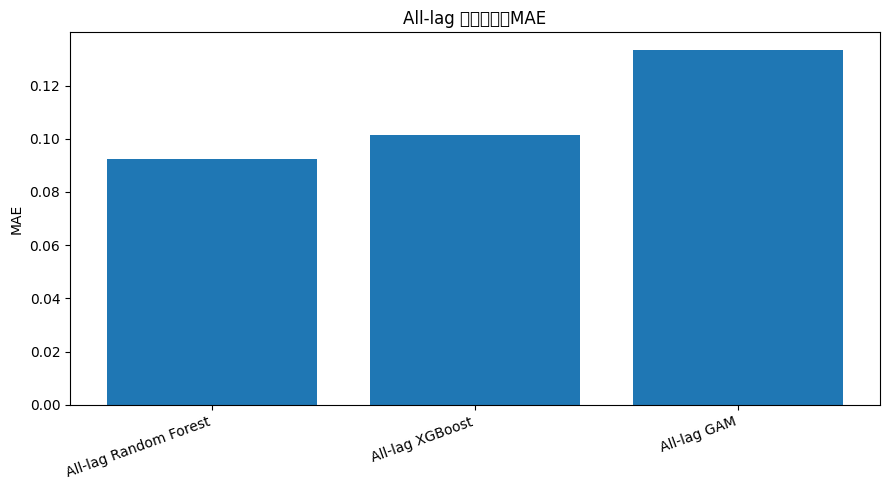

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_model_comparison_MAE.png


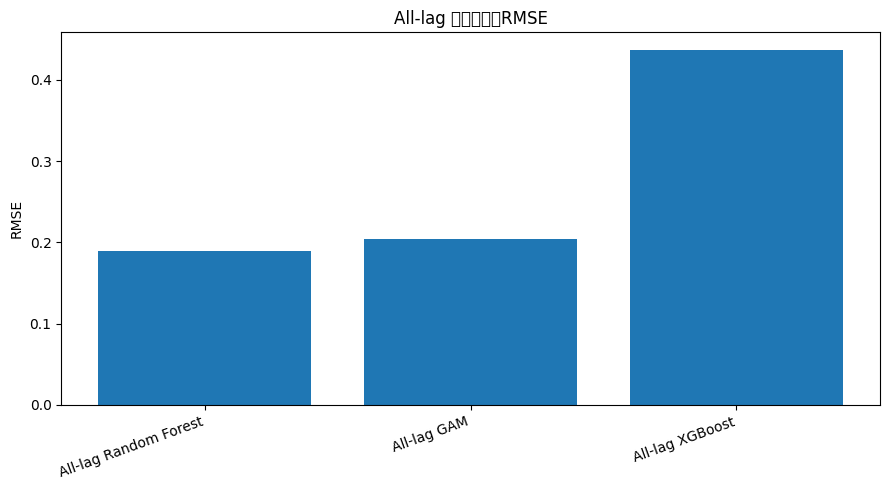

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_model_comparison_RMSE.png


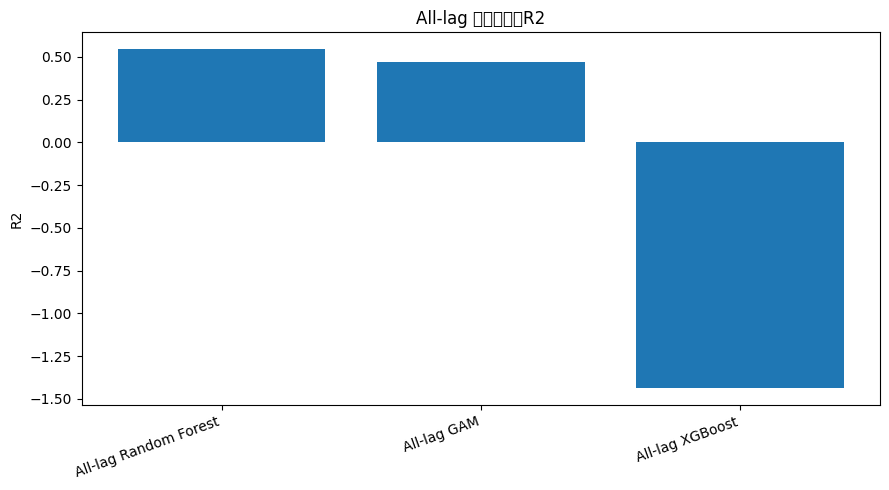

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_model_comparison_R2.png


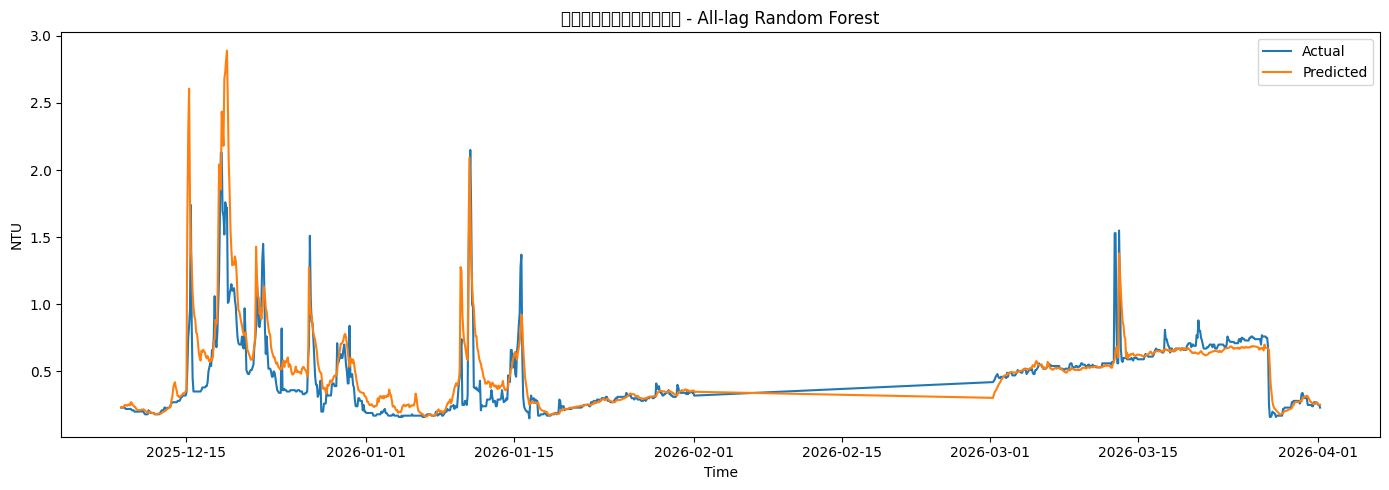

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_test_timeseries_All-lag_Random_Forest.png


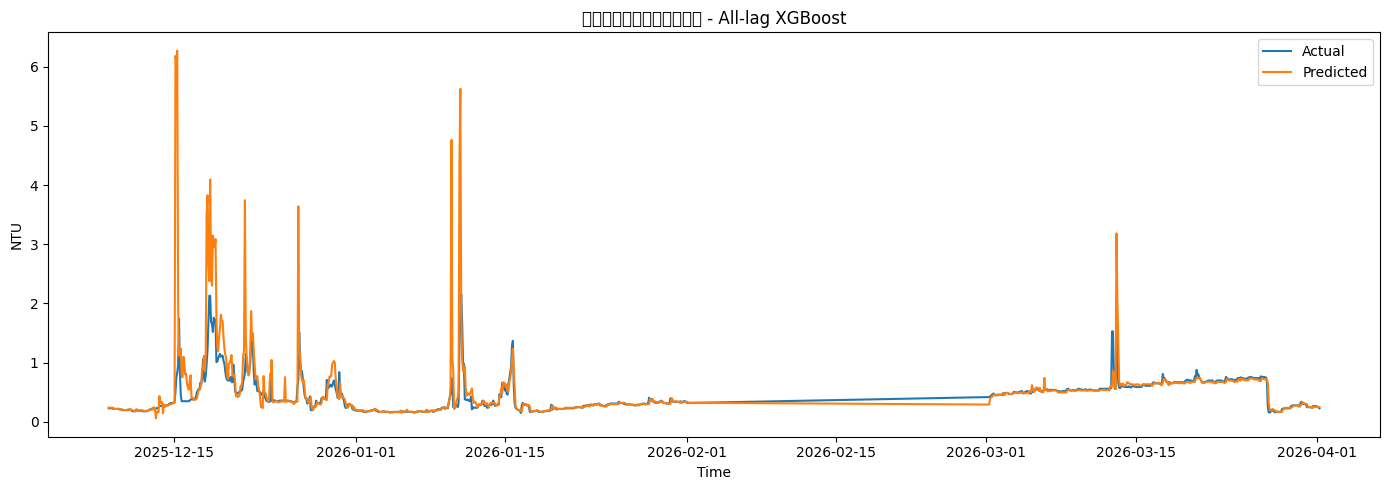

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_test_timeseries_All-lag_XGBoost.png


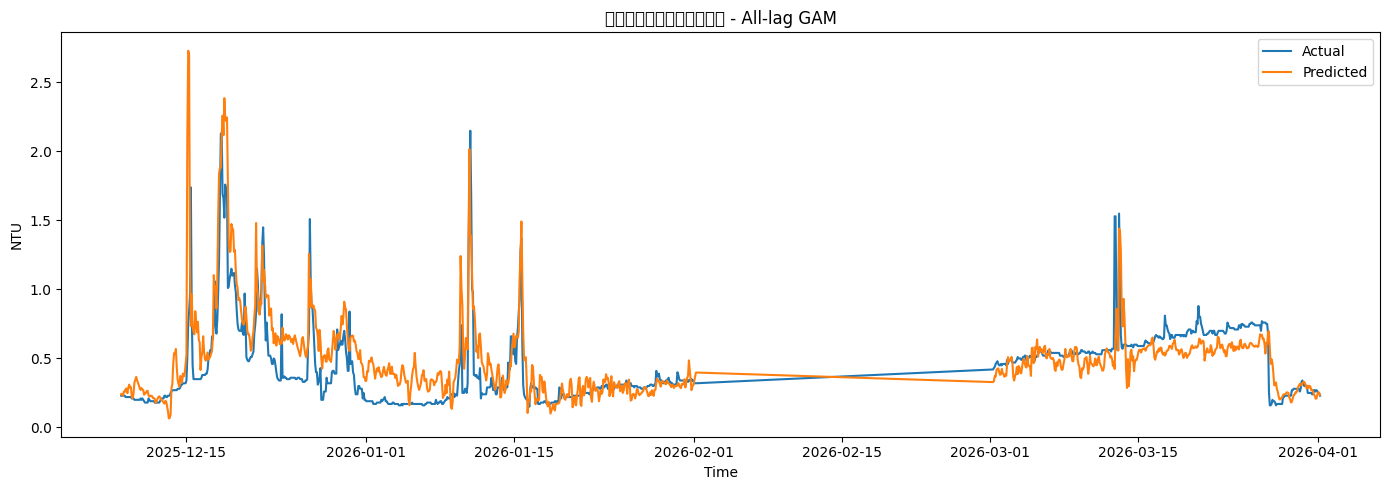

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_test_timeseries_All-lag_GAM.png


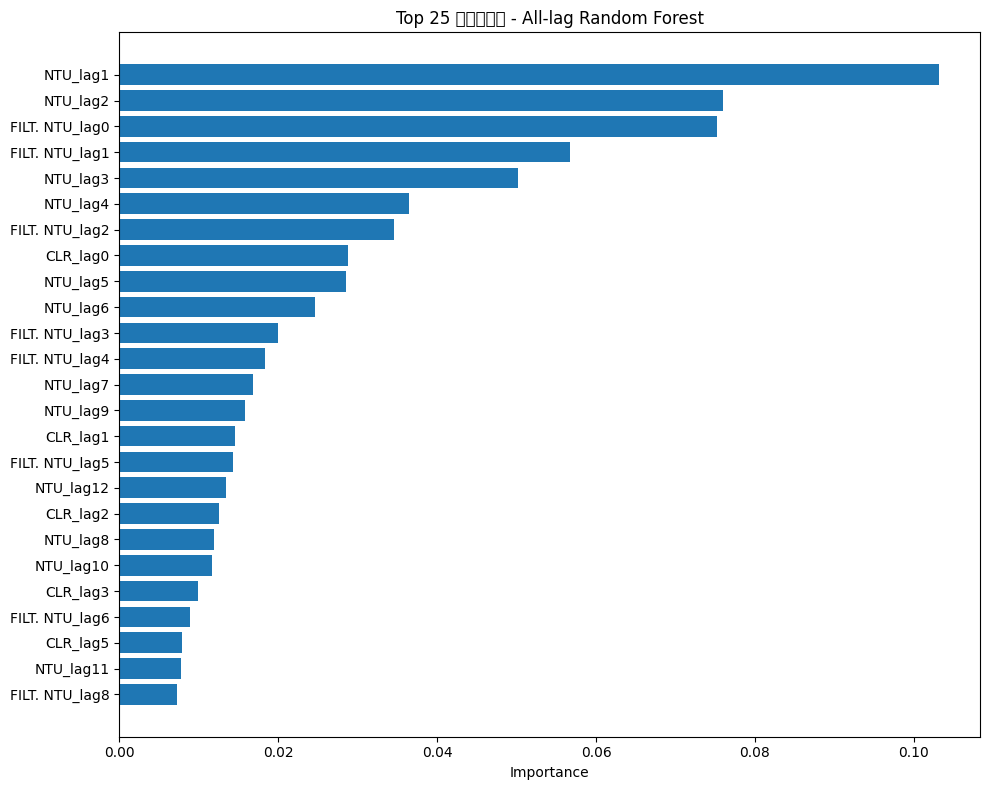

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_feature_importance_top25_All-lag_Random_Forest.png


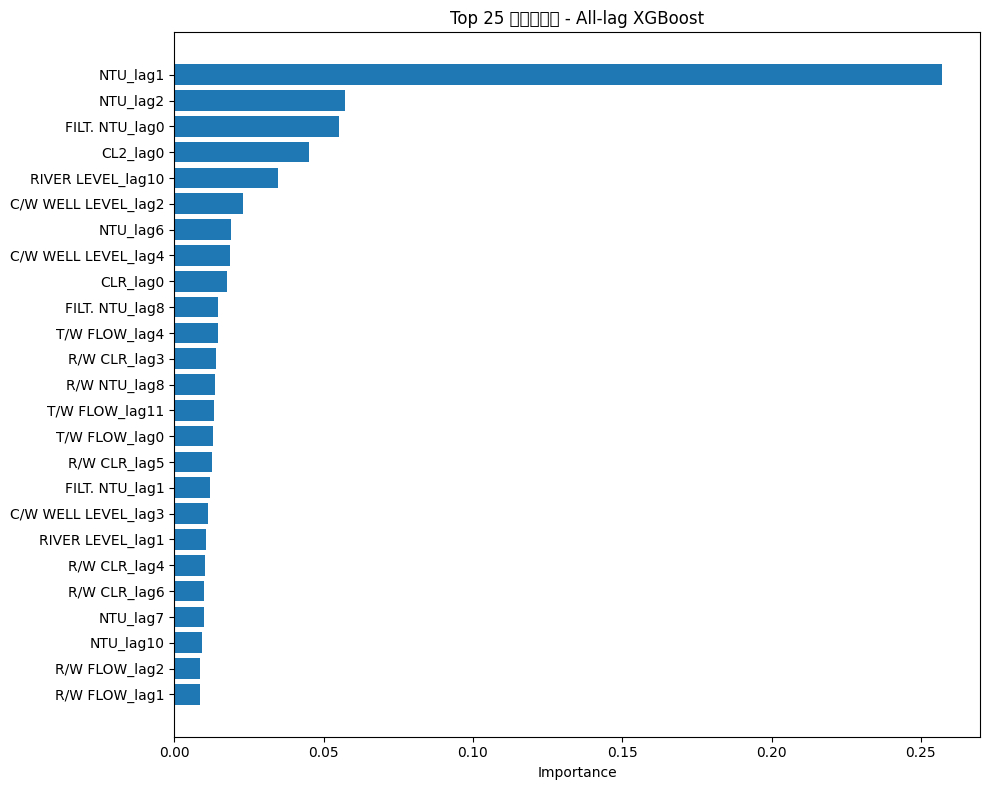

已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures\all_lag_feature_importance_top25_All-lag_XGBoost.png


In [16]:
# 16.1 模型指标对比图
for metric in ["MAE", "RMSE", "R2"]:
    temp = results_df.sort_values(metric, ascending=(metric != "R2"))

    plt.figure(figsize=(9, 5))
    plt.bar(temp["model"], temp[metric])
    plt.title(f"All-lag 模型对比：{metric}")
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    fig_path = FIG_DIR / f"all_lag_model_comparison_{metric}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("已保存：", fig_path)


# 16.2 测试集真实值与预测值时间序列
for model_name in test_predictions_df["model"].unique():
    temp = test_predictions_df[test_predictions_df["model"] == model_name].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(temp["TIMESTAMP"], temp["actual_NTU"], label="Actual", linewidth=1.5)
    plt.plot(temp["TIMESTAMP"], temp["predicted_NTU"], label="Predicted", linewidth=1.5)
    plt.title(f"测试集真实值与预测值对比 - {model_name}")
    plt.xlabel("Time")
    plt.ylabel("NTU")
    plt.legend()
    plt.tight_layout()

    safe_name = model_name.replace(" ", "_").replace("/", "_")
    fig_path = FIG_DIR / f"all_lag_test_timeseries_{safe_name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("已保存：", fig_path)


# 16.3 树模型 Top 25 特征重要性
if "importance_df" in globals() and len(importance_df) > 0:
    for model_name in importance_df["model"].unique():
        temp = importance_df[importance_df["model"] == model_name].head(25).copy()
        temp = temp.sort_values("importance", ascending=True)

        plt.figure(figsize=(10, 8))
        plt.barh(temp["feature"], temp["importance"])
        plt.title(f"Top 25 特征重要性 - {model_name}")
        plt.xlabel("Importance")
        plt.tight_layout()

        safe_name = model_name.replace(" ", "_").replace("/", "_")
        fig_path = FIG_DIR / f"all_lag_feature_importance_top25_{safe_name}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("已保存：", fig_path)


# 16.4 指定日期预测曲线
if "target_predictions_df" in globals() and len(target_predictions_df) > 0:
    for model_name in target_predictions_df["model"].unique():
        temp_model = target_predictions_df[target_predictions_df["model"] == model_name].copy()

        plt.figure(figsize=(14, 5))

        for op_date, temp_date in temp_model.groupby("OP_DATE"):
            plt.plot(
                temp_date["TIMESTAMP"],
                temp_date["predicted_NTU"],
                marker="o",
                label=str(op_date),
            )

        plt.title(f"指定日期预测 NTU - {model_name}")
        plt.xlabel("Timestamp")
        plt.ylabel("Predicted NTU")
        plt.legend()
        plt.tight_layout()

        safe_name = model_name.replace(" ", "_").replace("/", "_")
        fig_path = FIG_DIR / f"all_lag_target_dates_prediction_{safe_name}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("已保存：", fig_path)


## 17. 最终结果汇总

运行到这里后，需要重点查看：

```text
1. all_lag_model_results.xlsx
2. all_lag_feature_importance.xlsx
3. all_lag_target_dates_prediction_summary.xlsx
4. figures/ 文件夹中的图像
```

判断标准：

```text
1. 如果 all-lag 模型优于 selected-one-lag，说明更多滞后信息有价值；
2. 如果 all-lag 模型不如 selected-one-lag，说明过多滞后特征引入了噪声；
3. 如果 RF 仍然最优，可以继续选择 RF 作为主模型；
4. 如果 XGBoost 或 GAM 更优，需要结合 RMSE、R² 和可解释性综合判断。
```


In [17]:
print("=" * 80)
print("全变量滞后特征重新建模测试完成。")
print("=" * 80)

print("\n主要输出文件：")
print("1. 模型指标：", results_path)
print("2. 测试集预测：", pred_path)

if "importance_path" in globals():
    print("3. 特征重要性：", importance_path)

if "target_pred_path" in globals():
    print("4. 指定日期预测：", target_pred_path)
    print("5. 指定日期预测汇总：", target_summary_path)

print("6. 图片输出目录：", FIG_DIR)

print("\n按 RMSE 排序的模型结果：")
display(results_df)

print("\nRMSE 最优模型：")
display(results_df.iloc[[0]])


全变量滞后特征重新建模测试完成。

主要输出文件：
1. 模型指标： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_model_results.xlsx
2. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_test_predictions.xlsx
3. 特征重要性： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\all_lag_feature_importance.xlsx
6. 图片输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem1_all_lag\figures

按 RMSE 排序的模型结果：


,model,MAE,RMSE,R2,MAPE_percent,n_train,n_test,n_features
0,All-lag Random Forest,0.092391,0.188751,0.544377,22.066001,4099,1025,207
2,All-lag GAM,0.133313,0.203554,0.470106,37.306574,4099,1025,207
1,All-lag XGBoost,0.101335,0.436438,-1.435974,16.241707,4099,1025,207



RMSE 最优模型：


,model,MAE,RMSE,R2,MAPE_percent,n_train,n_test,n_features
0,All-lag Random Forest,0.092391,0.188751,0.544377,22.066001,4099,1025,207
